In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
import plotly.express as px

In [2]:
apps = pd.read_csv("googleplaystore.csv")

reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [3]:
apps.head()

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [4]:
apps.info()

apps.describe()

apps.isnull().sum()

apps.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


np.int64(483)

In [5]:
apps.drop_duplicates(inplace=True)

In [8]:
apps.dropna(subset=["Rating"], inplace=True)

apps["Type"] = apps["Type"].fillna("Free")

In [9]:
print(apps["Installs"].unique())

['10000' '500000' '5000000' '50000000' '100000' '50000' '1000000'
 '10000000' '5000' '100000000' '1000000000' '1000' '500000000' '100' '500'
 '10' '5' '50' '1' 'Free']


In [10]:
# Remove the corrupted row (Category = 1.9 / Installs = Free)
apps = apps[apps["Category"] != "1.9"]

# Clean the Installs column
apps["Installs"] = (
    apps["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

# Convert to integer
apps["Installs"] = pd.to_numeric(apps["Installs"], errors="coerce")

# Remove any remaining invalid values
apps = apps.dropna(subset=["Installs"])

# Convert to int
apps["Installs"] = apps["Installs"].astype(int)

# Check the result
print(apps["Installs"].head())
print(apps["Installs"].dtype)

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64
int64


In [11]:
apps["Price"] = apps["Price"].str.replace("$","")

apps["Price"] = apps["Price"].astype(float)

In [12]:
apps["Reviews"] = apps["Reviews"].astype(int)

In [13]:
apps["Category"].value_counts()

Category
FAMILY                 1718
GAME                   1074
TOOLS                   734
PRODUCTIVITY            334
FINANCE                 317
PERSONALIZATION         310
COMMUNICATION           307
LIFESTYLE               305
PHOTOGRAPHY             304
MEDICAL                 302
SPORTS                  286
BUSINESS                270
HEALTH_AND_FITNESS      262
SOCIAL                  244
NEWS_AND_MAGAZINES      214
TRAVEL_AND_LOCAL        205
SHOPPING                202
BOOKS_AND_REFERENCE     177
VIDEO_PLAYERS           160
DATING                  159
EDUCATION               129
MAPS_AND_NAVIGATION     124
ENTERTAINMENT           111
FOOD_AND_DRINK          106
WEATHER                  75
AUTO_AND_VEHICLES        73
HOUSE_AND_HOME           68
LIBRARIES_AND_DEMO       65
ART_AND_DESIGN           62
COMICS                   58
PARENTING                50
EVENTS                   45
BEAUTY                   42
Name: count, dtype: int64

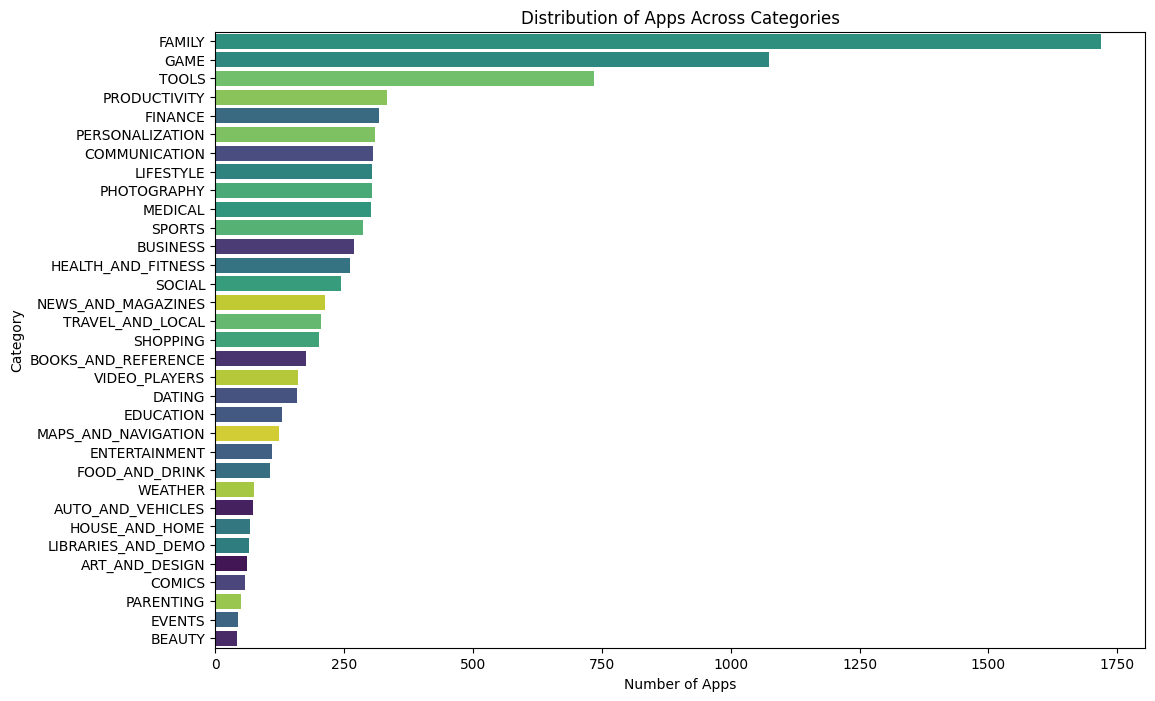

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.countplot(
    data=apps,
    y="Category",
    order=apps["Category"].value_counts().index,
    hue="Category",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Apps Across Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

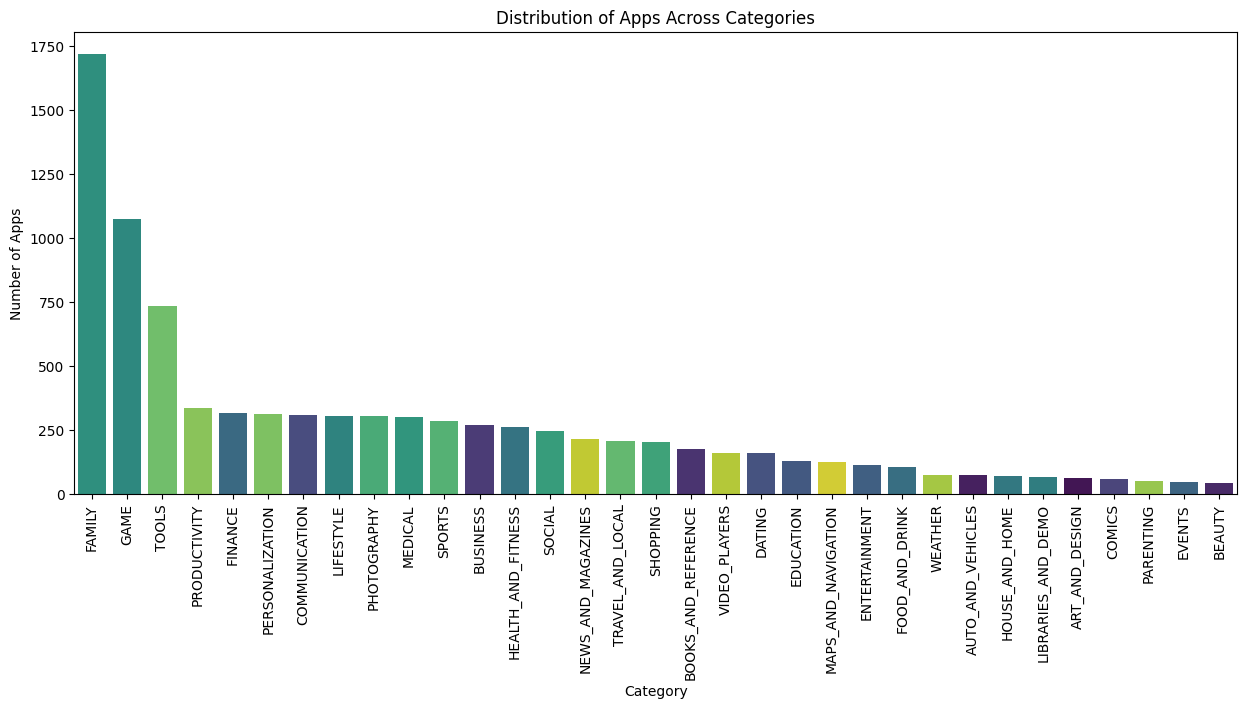

In [17]:
plt.figure(figsize=(15, 6))

sns.countplot(
    data=apps,
    x="Category",
    order=apps["Category"].value_counts().index,
    hue="Category",
    palette="viridis",
    legend=False
)

plt.xticks(rotation=90)
plt.title("Distribution of Apps Across Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.show()

In [18]:
top10 = apps["Category"].value_counts().head(10)

print(top10)

Category
FAMILY             1718
GAME               1074
TOOLS               734
PRODUCTIVITY        334
FINANCE             317
PERSONALIZATION     310
COMMUNICATION       307
LIFESTYLE           305
PHOTOGRAPHY         304
MEDICAL             302
Name: count, dtype: int64


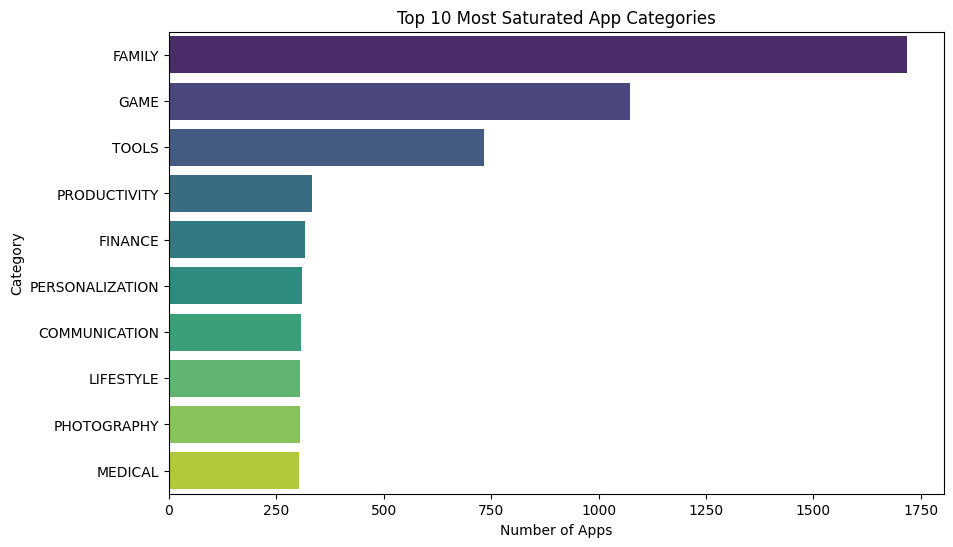

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Most Saturated App Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

<Axes: xlabel='Rating', ylabel='Count'>

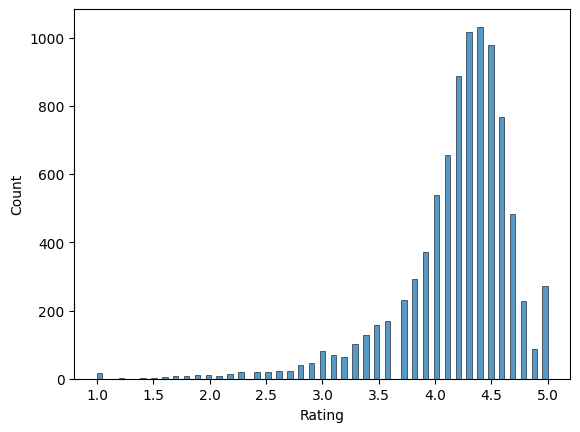

In [20]:
sns.histplot(apps["Rating"])

In [21]:
apps.groupby("Category")["Rating"].mean()

Category
ART_AND_DESIGN         4.358065
AUTO_AND_VEHICLES      4.190411
BEAUTY                 4.278571
BOOKS_AND_REFERENCE    4.347458
BUSINESS               4.102593
COMICS                 4.155172
COMMUNICATION          4.151466
DATING                 3.971698
EDUCATION              4.375969
ENTERTAINMENT          4.136036
EVENTS                 4.435556
FAMILY                 4.191153
FINANCE                4.127445
FOOD_AND_DRINK         4.164151
GAME                   4.281285
HEALTH_AND_FITNESS     4.261450
HOUSE_AND_HOME         4.164706
LIBRARIES_AND_DEMO     4.178462
LIFESTYLE              4.096066
MAPS_AND_NAVIGATION    4.051613
MEDICAL                4.182450
NEWS_AND_MAGAZINES     4.128505
PARENTING              4.300000
PERSONALIZATION        4.333871
PHOTOGRAPHY            4.182895
PRODUCTIVITY           4.201796
SHOPPING               4.251485
SOCIAL                 4.254918
SPORTS                 4.225175
TOOLS                  4.047411
TRAVEL_AND_LOCAL       4.094146

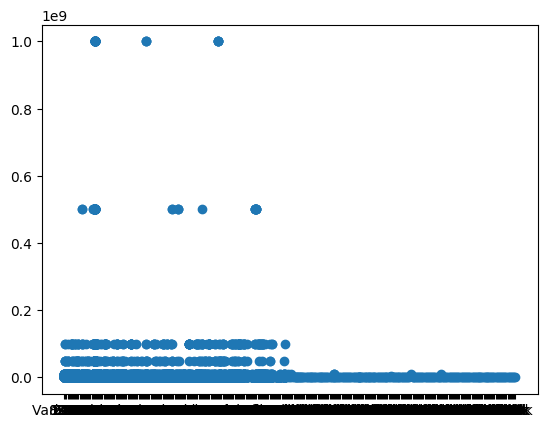

In [22]:
plt.scatter(apps["Size"], apps["Installs"])

In [23]:
apps["Type"].value_counts()

Type
Free    8279
Paid     613
Name: count, dtype: int64

In [24]:
paid = apps[apps["Type"]=="Paid"]

<Axes: xlabel='Price', ylabel='Count'>

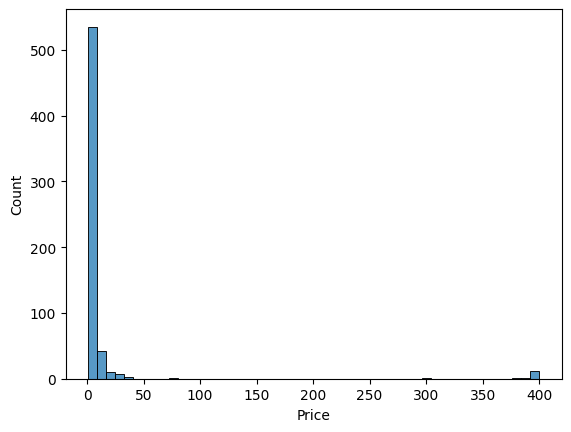

In [25]:
sns.histplot(paid["Price"])

In [29]:
print(apps["Price"].head())
print(apps["Price"].dtype)

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64
float64


In [30]:
apps["Price"] = (
    apps["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps["Price"] = pd.to_numeric(apps["Price"], errors="coerce").fillna(0)

In [31]:
apps["Revenue"] = apps["Price"] * apps["Installs"]

In [32]:
revenue_by_category = (
    apps.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_category)

Category
FAMILY                 1.857743e+08
LIFESTYLE              5.758394e+07
GAME                   4.098684e+07
FINANCE                2.572664e+07
PHOTOGRAPHY            8.941050e+06
MEDICAL                8.371355e+06
PERSONALIZATION        7.786310e+06
TOOLS                  5.462910e+06
SPORTS                 4.706154e+06
PRODUCTIVITY           4.304452e+06
COMMUNICATION          4.247100e+06
WEATHER                4.179885e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.420270e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.149250e+06
BUSINESS               1.047648e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      9.950000e+04
BOOKS_AND_REFERENCE    8.890150e+04
DATING                 8.758900e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6.445000e+03
SOCIAL             

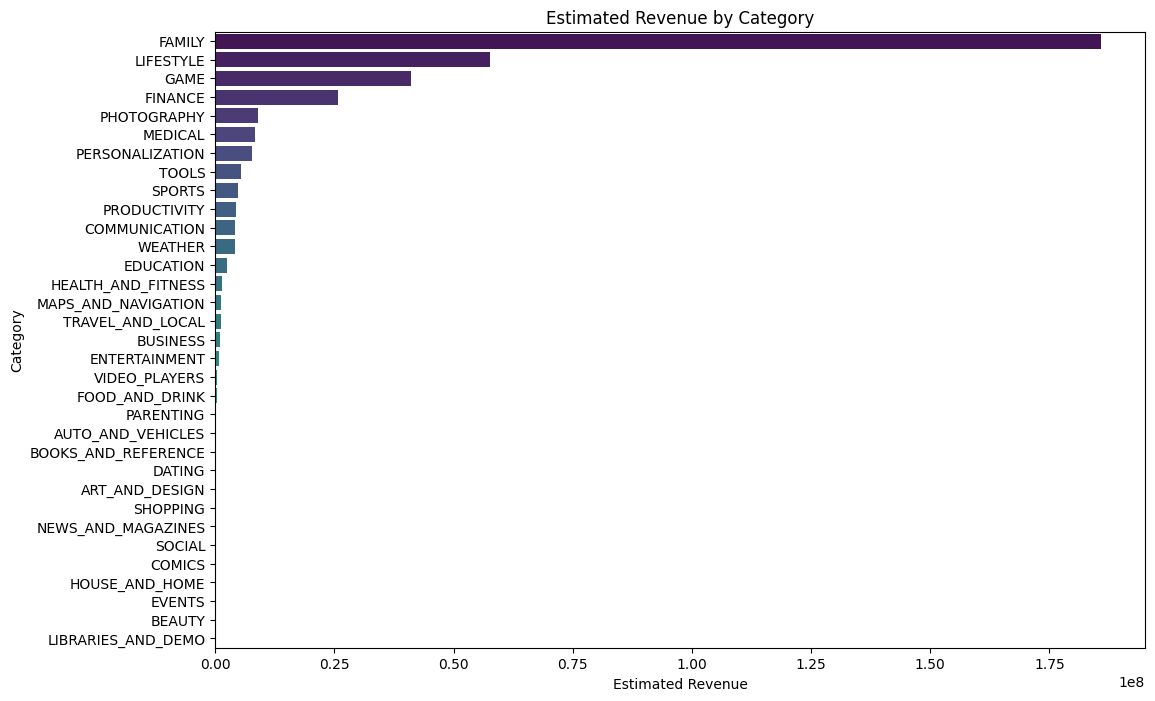

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.barplot(
    x=revenue_by_category.values,
    y=revenue_by_category.index,
    hue=revenue_by_category.index,
    palette="viridis",
    legend=False
)

plt.title("Estimated Revenue by Category")
plt.xlabel("Estimated Revenue")
plt.ylabel("Category")
plt.show()

In [34]:
print(apps.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Revenue'],
      dtype='object')


In [35]:
apps.groupby("Category")["Revenue"].sum()

Category
ART_AND_DESIGN         3.184000e+04
AUTO_AND_VEHICLES      9.950000e+04
BEAUTY                 0.000000e+00
BOOKS_AND_REFERENCE    8.890150e+04
BUSINESS               1.047648e+06
COMICS                 0.000000e+00
COMMUNICATION          4.247100e+06
DATING                 8.758900e+04
EDUCATION              2.403980e+06
ENTERTAINMENT          7.980000e+05
EVENTS                 0.000000e+00
FAMILY                 1.857743e+08
FINANCE                2.572664e+07
FOOD_AND_DRINK         2.844000e+05
GAME                   4.098684e+07
HEALTH_AND_FITNESS     1.420270e+06
HOUSE_AND_HOME         0.000000e+00
LIBRARIES_AND_DEMO     0.000000e+00
LIFESTYLE              5.758394e+07
MAPS_AND_NAVIGATION    1.240789e+06
MEDICAL                8.371355e+06
NEWS_AND_MAGAZINES     6.445000e+03
PARENTING              2.499590e+05
PERSONALIZATION        7.786310e+06
PHOTOGRAPHY            8.941050e+06
PRODUCTIVITY           4.304452e+06
SHOPPING               3.014900e+04
SOCIAL             

In [36]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [37]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [38]:
def sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity>0:
        return "Positive"

    elif polarity<0:
        return "Negative"

    else:
        return "Neutral"

In [39]:
reviews["Sentiment"] = reviews["Translated_Review"].apply(sentiment)

In [40]:
reviews["Sentiment"].value_counts()

Sentiment
Neutral     32026
Positive    23997
Negative     8272
Name: count, dtype: int64

In [41]:
merged = pd.merge(reviews,
                  apps,
                  on="App")

In [42]:
merged.groupby(["Category","Sentiment"]).size()

Category           Sentiment
ART_AND_DESIGN     Negative      61
                   Neutral      228
                   Positive     259
AUTO_AND_VEHICLES  Negative      17
                   Neutral      350
                               ... 
VIDEO_PLAYERS      Neutral      227
                   Positive     190
WEATHER            Negative      34
                   Neutral       82
                   Positive     164
Length: 99, dtype: int64

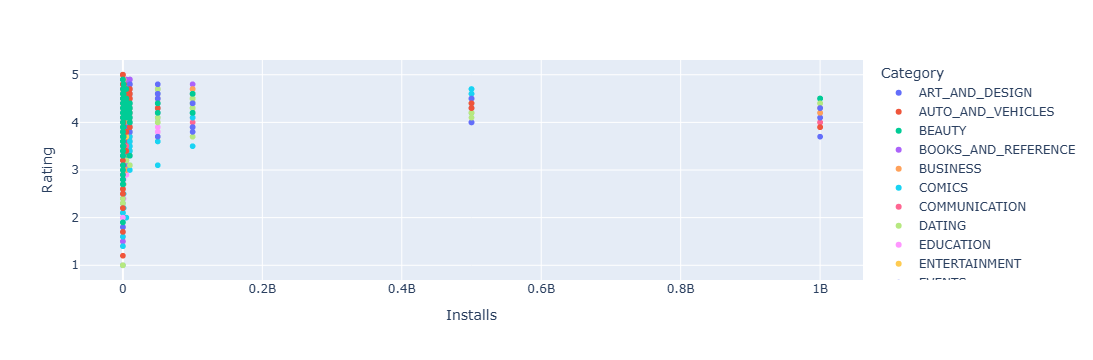

In [43]:
fig = px.scatter(
    apps,
    x="Installs",
    y="Rating",
    color="Category"
)

fig.show()

In [44]:
apps.to_csv("cleaned_googleplaystore.csv", index=False)

reviews.to_csv("cleaned_reviews.csv", index=False)

In [45]:
# Save cleaned datasets
apps.to_csv("cleaned_googleplaystore.csv", index=False)
reviews.to_csv("cleaned_reviews.csv", index=False)

print("✅ cleaned_googleplaystore.csv saved successfully.")
print("✅ cleaned_reviews.csv saved successfully.")

✅ cleaned_googleplaystore.csv saved successfully.
✅ cleaned_reviews.csv saved successfully.


In [46]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in the folder:")
print(os.listdir())

Current Folder:
C:\Users\saisr\OneDrive\Desktop\Google_Play_Store_Analysis-Level2-Task4

Files in the folder:
['.ipynb_checkpoints', 'cleaned_googleplaystore.csv', 'cleaned_reviews.csv', 'googleplaystore.csv', 'GooglePlayStoreAnalysis-Level2-Task4.ipynb', 'googleplaystore_user_reviews.csv']


In [47]:
cleaned_apps = pd.read_csv("cleaned_googleplaystore.csv")
cleaned_reviews = pd.read_csv("cleaned_reviews.csv")

print(cleaned_apps.head())
print(cleaned_reviews.head())

                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

   Reviews  Size  Installs  Type  Price Content Rating  \
0      159   19M     10000  Free    0.0       Everyone   
1      967   14M    500000  Free    0.0       Everyone   
2    87510  8.7M   5000000  Free    0.0       Everyone   
3   215644   25M  50000000  Free    0.0           Teen   
4      967  2.8M    100000  Free    0.0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend Play  